In [2]:
from collections import defaultdict
from pathlib import Path

import colorcet as cc
import equinox as eqx
import h5py
import jax
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from context_flux_no.metrics import relative_L2_error, relative_L_infty_error
from context_flux_no.plotting.lineplots import plot_mean_and_std
from context_flux_no.training.io import load_model
from einops import rearrange
from tqdm import tqdm


plt.style.use("context_flux_no.plotting.styles.dash_gridded")

COLOR_DICT = {
    "DPOT": cc.cm.glasbey_bw(85),
    "ICON": cc.cm.glasbey_bw(1),
    "DISCO": cc.cm.glasbey_bw(68),
    "HyperFluxFNOLocal": cc.cm.glasbey_bw(41),
}

LABEL_DICT = {
    "DPOT": "DPOT",
    "ICON": "ICON",
    "DISCO": "DISCO",
    "HyperFluxFNOLocal": "HFluxNO (Ours)",
}
datadir = Path("../../data")
checkpoint_dir = Path("../../checkpoints")

jax.config.update("jax_default_device", jax.devices("gpu")[0])

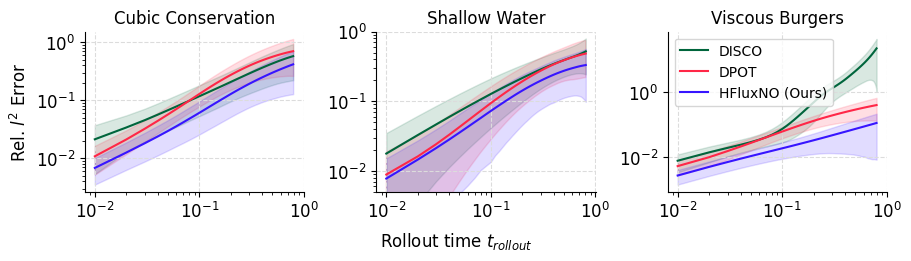

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(9, 2.5), constrained_layout=True, sharex=True)

DATASET_NAME_DICT={"cubic": "Cubic Conservation", "shallow_water": "Shallow Water", "burgers": "Viscous Burgers"}
dt=0.01
for ax, dataset_name in zip(axes, ("cubic", "shallow_water", "burgers")):
    with h5py.File(f"../../data/analysis/{dataset_name}_1d_long_rollout.hdf5", "r") as f:
        for model_type, res in f.items():
            # for i in range(4):
            #     ax.axvline(x=(5 * 2**i - 1) * dt, ls="--", color="gray", alpha=0.7)
            l2 = res["l2"][0]
            ax = plot_mean_and_std(
                ax,
                np.arange(1, l2.shape[1] + 1) * dt,
                l2,
                color=COLOR_DICT[model_type],
                label=LABEL_DICT[model_type],
                alpha_band=0.15,
            )


        ax.set_yscale("log")
        ax.set_xscale("log")
        ax.set_title(DATASET_NAME_DICT[dataset_name], fontsize="medium")
fig.supxlabel("Rollout time $t_{rollout}$", fontsize="medium")
axes[0].set_ylabel("Rel. $l^2$ Error")
axes[-1].legend(fontsize="small", loc="upper left")
axes[1].set_ylim((5e-3,1))
fig.savefig("../../figures/fig2/rollout_l2.pdf", dpi=500)

## Compute rolled out trajectories for seed=0, and for a fixed trajectory

In [ ]:
dataset_test = (
    xr.open_dataset(
        datadir
        / "datasets/cubic_no_source/data/test/cubic_no_source_large_test_seed=10.hdf5",
        engine="h5netcdf",
        chunks={},
    )
    .isel(t=slice(None, None, 10))
    .isel({"t": slice(0, 99)})
)
dt = float(dataset_test["t"][1] - dataset_test["t"][0])
dx = float(dataset_test["x"][1] - dataset_test["x"][0])

values = rearrange(dataset_test["values"].values, "pde ic ... -> (pde ic) ...")